In [ ]:
%pip install pandas numpy<2 seaborn kmodes scikit-learn lifelines gower prince scipy kmodes gower

### Load and transform

In [144]:
import pandas as pd
import time

pd.set_option('future.no_silent_downcasting',True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = "C:/Users/Acer/Downloads/original_customer_data.csv"
start = time.time()
df = pd.read_csv(path)
print(f"✅ File '{path.rpartition('/')[2]}' loaded in {round(time.time() - start, 2)} secs!")

✅ File 'original_customer_data.csv' loaded in 0.46 secs!


### 💰 Understanding Monetary Columns
- Since ```Total_Revenue = (Total_Charges + Total_Long_Distance_Charges + Total_Extra_Data_Charges) - Total_Refunds```, a new calculated column was created - ```Monthly_Avg``` - for abridging the all-time customer monthly value.  

In [145]:
print(df[['Tenure_in_Months', 'Monthly_Charge', 'Total_Charges', 
          'Total_Refunds', 'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
          'Total_Revenue']].iloc[[0]])

df['Monthly_Avg'] = round(df['Total_Revenue'] / df['Tenure_in_Months'], 2)

   Tenure_in_Months  Monthly_Charge  Total_Charges  Total_Refunds  \
0                27            65.6          593.3            0.0   

   Total_Extra_Data_Charges  Total_Long_Distance_Charges  Total_Revenue  
0                         0                       381.51         974.81  


### 🔎 Filling service-related nulls with 'No'

In [146]:
no_phone = df['Phone_Service'] == 'No'
null_multi = df['Multiple_Lines'].isna()

if (no_phone & ~null_multi).sum() == 0:
    print(f"\u2713 The {no_phone.sum()} 'No' rows for Phone_Service match the nulls of Multiple_Lines. Altering those nulls to 'No':")
    df.loc[null_multi, 'Multiple_Lines'] = 'No'
    print(df['Multiple_Lines'].value_counts(dropna = False))
    print("-" * 60)

has_nulls = df.isna().any().drop(['Value_Deal', 'Multiple_Lines', 'Phone_Service', 'Churn_Category', 'Churn_Reason']).copy()
internet_related = has_nulls[has_nulls]

no_internet = df['Internet_Service'] =='No'

for i in internet_related.index.tolist():
    null_values = df[i].isna()
    if (null_values & ~no_internet).sum() == 0:
        print(f"\u2713 The {no_internet.sum()} 'No' rows of Internet_Service match the nulls of {i}. Altering those nulls to 'No': ")
        df.loc[null_values, i] = 'No'
        print(df[i].value_counts(dropna = False))
        print("-" * 60)

✓ The 622 'No' rows for Phone_Service match the nulls of Multiple_Lines. Altering those nulls to 'No':
Multiple_Lines
No     3704
Yes    2714
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Internet_Type. Altering those nulls to 'No': 
Internet_Type
Fiber Optic    2764
DSL            1502
No             1390
Cable           762
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Online_Security. Altering those nulls to 'No': 
Online_Security
No     4594
Yes    1824
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Online_Backup. Altering those nulls to 'No': 
Online_Backup
No     4210
Yes    2208
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' ro

### 🚩 Oultier dealing (Tukey)

- ```Total_Extra_Data_Charges``` and ```Total_Refunds``` are mostly populated by 0, so using the median replaces all values (considered as outliers) with 0.
- ```Total_Revenue``` and ```Total_Long_Distance_Charges``` tallied 19 and 193 outliers respec., and had the median replacement.

In [147]:
num_cols = df.select_dtypes(include = ['float64', 'int64']).columns.to_list()
num_cols = [i for i in num_cols if i not in ('Total_Extra_Data_Charges', 'Total_Refunds')]

og_outliers = {}
outliers = {}
medians = {}
for i in num_cols:
    q1 = df[i].quantile(.25)
    q3 = df[i].quantile(.75)

    IQR = q3 - q1

    sup = q3 + 1.5 * IQR
    inf = q1 - 1.5 * IQR

    mask = (df[i] > sup) | (df[i] < inf)
    og_outliers[i] = df[mask].index.tolist()
    
    median = df[i].median() # returns float per default
    if pd.api.types.is_integer_dtype(df[i].dtype):
        median = int(round(median))
    else:
        median = median
        
    medians[i] = median 

    df.loc[mask, i] = median
    mask_updated = (df[i] > sup) | (df[i] < inf)
    
    outliers[i] = df[mask_updated].index.tolist()

medians_df = pd.DataFrame.from_dict({
    "Column": medians.keys(),
    "Col_dtype": [df[i].dtype for i in medians.keys()],
    "Median": medians.values(),
    "Median_dtype": [type(v).__name__ for v in medians.values()]
    })

og_outliers_df = pd.DataFrame.from_dict(
    {"Column": og_outliers.keys(),
     "Outlier_Count": [len(v) for v in og_outliers.values()],
     "Outlier_%": [len(v)/len(df)*100 for v in og_outliers.values()]
     #,"Outlier_indices": outliers.values()
    })

# Mask slices the df to show only outliers. Each column becomes a dict key, and its' values are the indices for each outlier.
outlier_df = pd.DataFrame.from_dict(
    {"Column": outliers.keys(),
     "Outlier_Count": [len(v) for v in outliers.values()],
     "Outlier_%": [len(v)/len(df)*100 for v in outliers.values()]
     #,"Outlier_indices": outliers.values()
    })

print("🔍 Median info for all columns:")
print(medians_df)
print("=" * 65)
print("🚩 Original outlier detection:")
print(og_outliers_df.sort_values('Outlier_%', ascending = False))
print("=" * 57)
print("✅ Updated outlier detection:")
print(outlier_df.sort_values('Outlier_%', ascending = False))

# non_scaled holds outliers delt, cleaned data plus pre-log Monthly_Avg  
non_scaled = df.copy()

🔍 Median info for all columns:
                        Column Col_dtype    Median Median_dtype
0                          Age     int64    46.000          int
1          Number_of_Referrals     int64     7.000          int
2             Tenure_in_Months     int64    16.000          int
3               Monthly_Charge   float64    70.100      float64
4                Total_Charges   float64  1396.125      float64
5  Total_Long_Distance_Charges   float64   407.475      float64
6                Total_Revenue   float64  2108.635      float64
7                  Monthly_Avg   float64   138.045      float64
🚩 Original outlier detection:
                        Column  Outlier_Count  Outlier_%
7                  Monthly_Avg            681  10.610782
5  Total_Long_Distance_Charges            193   3.007167
6                Total_Revenue             19   0.296042
0                          Age              0   0.000000
1          Number_of_Referrals              0   0.000000
2             Tenure_

### 🔢 Scale numericals
- Resistant to remaining outliers, no distortion on distances (unlike Min/Max and StandardScaler, easily skewed). The best match for KMedoids.
- Standard Scaler for KPrototypes

In [148]:
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

df['Monthly_Avg'] = np.log1p(df['Monthly_Avg'])

#scaler = RobustScaler()
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

data = df[['Contract', 
           #'Monthly_Charge', 
           'Monthly_Avg',
           'Tenure_in_Months',
           'Internet_Type',
           #'Married', 
           #'Tenure_in_Months',
           #'Age'
    ]].copy()

for i in data.select_dtypes(include = ['float64', 'int64']).columns.to_list():
    print("🤖 ✔ Numerical (originally {}) data scaled for {}!".format(non_scaled[i].dtype, i))

🤖 ✔ Numerical (originally float64) data scaled for Monthly_Avg!
🤖 ✔ Numerical (originally int64) data scaled for Tenure_in_Months!


### 🥪 FAMD (Factor Analysis of Mixed Data) 

#### Contributions
- By analysing each dimension and the barplot, ```Tenure_in_Months```, a seemingly important feature for customer profiling, appears to be too homogenous to hold relevant variance.

Expected average contribution cutoff: 25.00%
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              1.528        21.82%                     21.82%
1              1.211        17.31%                     39.13%
2              1.031        14.73%                     53.86%
3              1.011        14.44%                     68.30%
4              0.969        13.84%                     82.14%
5              0.905        12.93%                     95.07%


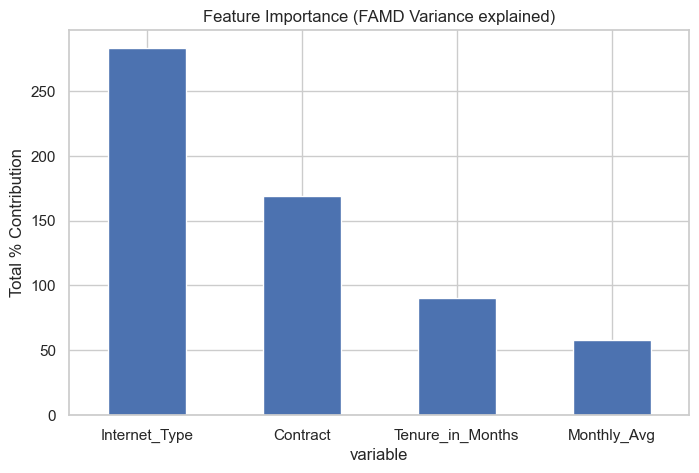

In [149]:
import prince
import matplotlib.pyplot as plt
import seaborn as sns

n_dim = 6

famd = prince.FAMD(
    n_components = n_dim,
    n_iter = 15,
    copy = True,
    check_input = True,
    random_state = 42)
famd.fit(data)

contr = famd.column_contributions_ * 100
dim0 = contr[0]
dim1 = contr[1]
dim2 = contr[2]

dim0_pct = (dim0/dim0.sum()) * 100
dim1_pct = (dim1/dim1.sum()) * 100
dim2_pct = (dim2/dim2.sum()) * 100

#print(dim0_pct.sort_values(ascending = False))

threshold = 100/len(contr)

print("Expected average contribution cutoff: {:.2f}%".format(threshold))

print(famd.eigenvalues_summary)

contr = famd.column_contributions_.sum(axis = 1).sort_values(ascending = False)

plt.figure(figsize = (8,5))
(contr * 100).plot(kind='bar')
plt.title('Feature Importance (FAMD Variance explained)')
plt.ylabel('Total % Contribution')
plt.xticks(rotation=0)
plt.show()

#### Unused FAMD plots

### K-Prototypes
- Isolated clusters worse than K-Medoids, even with high γ.

In [23]:
import gower

print("🔬 Starting Gower Matrix...\n")
start = time.time()
dist_matrix = gower.gower_matrix(data)
print(f"✓ Gower Matrix computed in {round(time.time() - start, 0)} secs")

🔬 Starting Gower Matrix...

✓ Gower Matrix computed in 30.0 secs


In [35]:
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

cat_cols = data.select_dtypes(include=('object', 'category'))
cat_indices = [data.columns.get_loc(c) for c in cat_cols]

print("🔬 Starting K-Prototypes...\n")
gamma = 1.0
print(f"Gamma (γ) used: {gamma}")
start = time.time()
k = 5
kproto = KPrototypes(n_clusters = k, 
                     init= 'Huang', 
                     n_init =5, 
                     verbose = 0,
                     gamma = gamma,
                     random_state = 42, 
                     n_jobs=-1)
kp_clusters = kproto.fit_predict(data, categorical=cat_indices)
non_scaled['Clusters'] = kp_clusters + 1
print("🤖 💬 K-Prototypes finished with {} clusters in {} secs!".format(k, round(time.time() - start, 2)))

score = silhouette_score(dist_matrix, kp_clusters, metric='precomputed')
# DBI demands numerical data.
DBI = davies_bouldin_score(data.select_dtypes(include=[np.number]), kp_clusters)

print("⚫ Silhouette score: {:.2f}".format(score))
print("⬜ DBI score: {:.2f}".format(DBI))

🔬 Starting K-Prototypes...

Gamma (γ) used: 1.0
🤖 💬 K-Prototypes finished with 5 clusters in 45.01 secs!
⚫ Silhouette score: 0.15
⬜ DBI score: 1.68


In [36]:
agg_dict = {}
for col in data.columns:
    if col in non_scaled.select_dtypes(include = [np.number]).columns:
        agg_dict[col] = 'mean'
    else: 
        agg_dict[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else None

agg_dict_df = pd.DataFrame.from_dict(agg_dict, orient = 'index')

profiles = non_scaled.groupby('Clusters').agg(agg_dict).reset_index()
print("-" * 75)
print(profiles)

---------------------------------------------------------------------------
   Clusters        Contract  Monthly_Avg  Tenure_in_Months Internet_Type
0         0  Month-to-Month   257.781121          7.224830   Fiber Optic
1         1  Month-to-Month    28.185307         12.214773            No
2         2        Two Year   309.952973         11.692720           DSL
3         3  Month-to-Month   144.687435         28.138008   Fiber Optic
4         4  Month-to-Month    11.126769         28.197062            No


### 🖼 K-Medoids 

#### Elbow plot
- Total_Revenue is directly related to Monthly_Charge. The inclusion of Tenure increased variance, and allows Survivability Analysis approachs to show differences. 
- Opted cluster number: 5

#### K-Medoids Clustering

In [150]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn_extra.cluster import KMedoids
import time

x_cluster = famd.row_coordinates(data).iloc[:, :6]

print("🔬 Starting K-Medoids...\n")
start2 = time.time()
k = 5
kmedoids = KMedoids(n_clusters=k, metric='euclidean', method = 'pam', random_state=0)
non_scaled['Clusters']  = kmedoids.fit_predict(x_cluster) + 1
print("🤖 💬 K-Medoids finished with {} clusters in {} secs!".format(k, round(time.time() - start2, 2)))

# metrics expect euclidean distances, which are in FAMD coords
score = silhouette_score(x_cluster, non_scaled['Clusters'])
DBI = davies_bouldin_score(x_cluster, non_scaled['Clusters'])
CHI = calinski_harabasz_score(x_cluster, non_scaled['Clusters'])

print("⚫ Silhouette score: {:.2f}".format(score))
print("⬜ DBI score: {:.2f}".format(DBI))
print("⚪ CHI score: {:.2f}".format(CHI))

🔬 Starting K-Medoids...

🤖 💬 K-Medoids finished with 5 clusters in 60.11 secs!
⚫ Silhouette score: 0.34
⬜ DBI score: 1.19
⚪ CHI score: 1780.90


#### 📊 Mean of Tenure and Charge by clusters

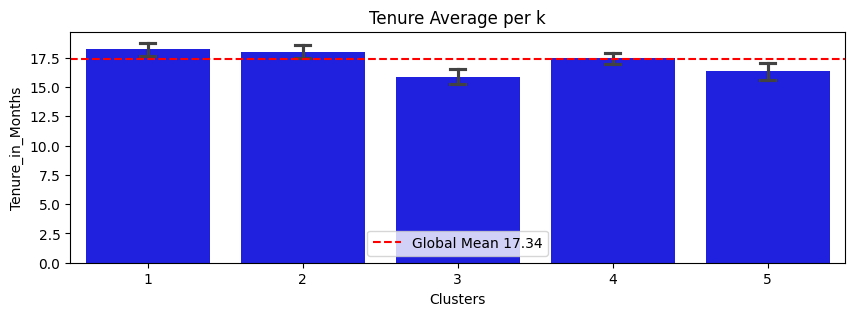

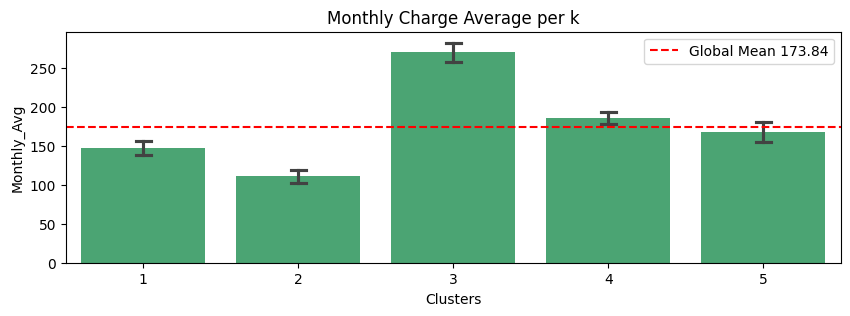

In [71]:
plt.figure(figsize=(10,3))
sns.barplot(data=non_scaled, x='Clusters', y='Tenure_in_Months', capsize=.1, color='blue', legend = False)
plt.title(f'Tenure Average per k')
plt.axhline(non_scaled['Tenure_in_Months'].mean(), color ='red', linestyle='--',
            label = 'Global Mean ' + str(round(non_scaled['Tenure_in_Months'].mean(), 2)))
plt.legend()
plt.show()

plt.figure(figsize=(10,3))
sns.barplot(data=non_scaled, x='Clusters', y='Monthly_Avg', capsize=.1, color='mediumseagreen', legend = False)
plt.title(f'Monthly Charge Average per k')
plt.axhline(non_scaled['Monthly_Avg'].mean(), color ='red', linestyle='--', 
            label = 'Global Mean ' + str(round(non_scaled['Monthly_Avg'].mean(), 2)))
plt.legend()
plt.show()

#### Checking cluster medoids + distribution
- Iterate over the list of features chosen from FAMD; means for numerical types, modes for categoricals

          Total Count  Data %
Clusters                     
4                2231   34.76
1                1381   21.52
2                1142   17.79
3                 902   14.05
5                 762   11.87
---------------------------------------------------------------------------
   Clusters Internet_Type        Contract  Tenure_in_Months  Monthly_Avg
0         1           DSL  Month-to-Month         18.210717   146.907552
1         2            No        Two Year         17.984238   111.112868
2         3   Fiber Optic        One Year         15.838137   270.645410
3         4   Fiber Optic  Month-to-Month         17.429404   185.526564
4         5         Cable  Month-to-Month         16.335958   167.888550
---------------------------------------------------------------------------
Customer_Status    Churned     Joined     Stayed
Clusters                                        
1                20.275163   7.530775  72.194062
2                 9.106830  14.623468  76.269702
3   

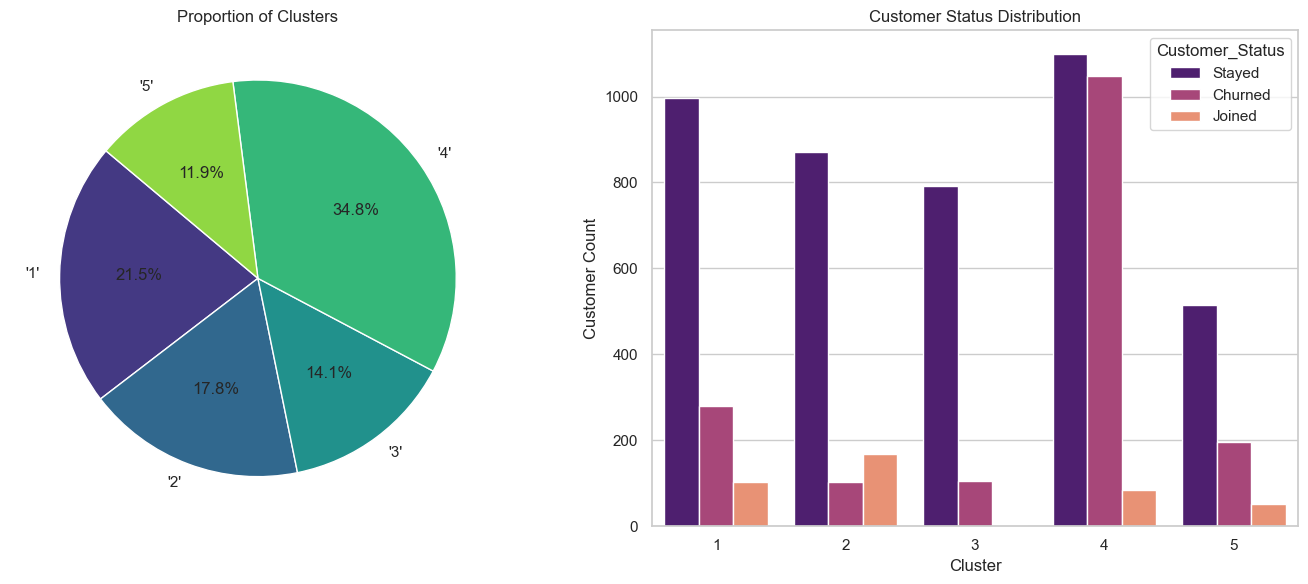

In [103]:
features = contr[contr * 100 > threshold].index.tolist()
#print("{} features surpassed average significance threshold ({:.2f}%) across dimensions:".format(len(features), threshold)) 
#print(features)

agg_dict = {}
for col in features:
    if col in non_scaled.select_dtypes(include = [np.number]).columns:
        agg_dict[col] = 'mean'
    else: 
        agg_dict[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else None

#agg_dict |= {'Monthly_Avg': 'count'}

profiles = non_scaled.groupby('Clusters').agg(agg_dict).reset_index()

counts= non_scaled['Clusters'].value_counts(dropna=False)
proportions = round(non_scaled['Clusters'].value_counts(normalize=True) * 100, 2)

summary= pd.concat([counts, proportions], axis = 1)
summary.columns = ['Total Count', 'Data %']
print(summary)

print("-" * 75)
print(profiles)
print("-" * 75)
print(pd.crosstab(non_scaled['Clusters'], non_scaled['Customer_Status'], normalize = 'index') * 100)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
cluster_counts = non_scaled['Clusters'].value_counts().sort_index()
plt.pie(cluster_counts,
        labels=[f"'{i}'" for i in cluster_counts.index],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("viridis", len(cluster_counts)))
plt.title('Proportion of Clusters')

plt.subplot(1,2,2)
sns.countplot(data= non_scaled, x='Clusters', hue= non_scaled['Customer_Status'], palette='magma')
plt.title('Customer Status Distribution')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

### 📉 Kaplan-Meier Curve
- In the 80% and median survivability test, _inf_ means _infinity_; 50%+ of the segment has outlasted the max months.

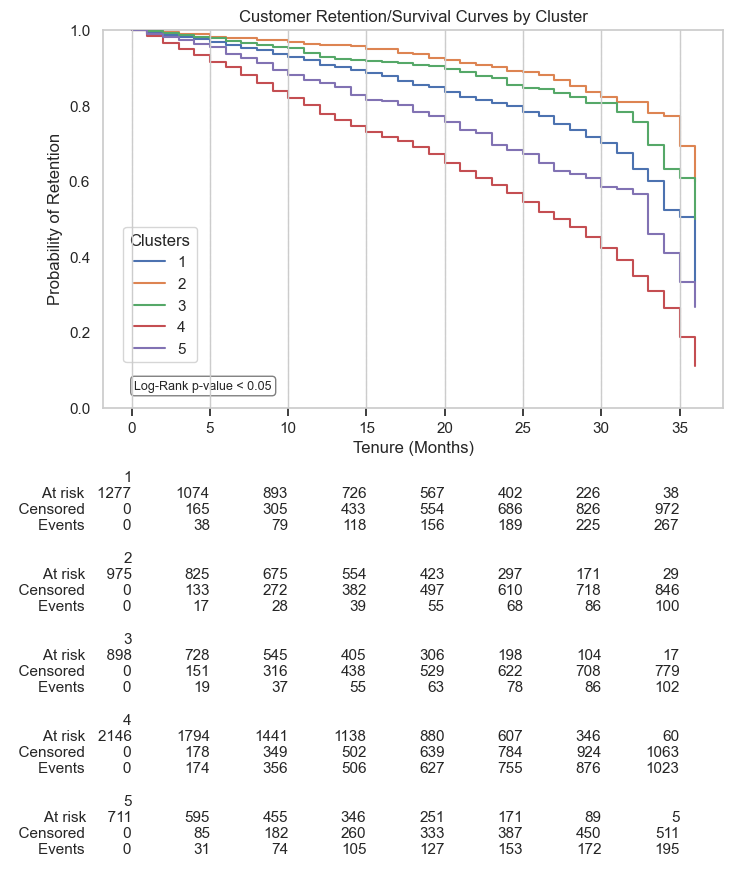

Clusters
4    2146
1    1277
2     975
3     898
5     711
Name: count, dtype: int64
------------------------------------------------------------
   Cluster  80% Surv hit (months)  Median Surv hit (months)
0        5                   18.0                      33.0
1        4                   12.0                      28.0
2        1                   24.0                      36.0
3        3                   31.0                       inf
4        2                   33.0                       inf


In [135]:
from lifelines import KaplanMeierFitter
from lifelines.utils import qth_survival_times
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

churn_stayed = non_scaled.copy()[non_scaled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

#churn_stayed['Clusters'] = churn_stayed['Clusters'].map(cluster_names)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)

fitters = []
for cluster in sorted(churn_stayed['Clusters'].unique()):
    mask_cluster = (churn_stayed['Clusters'] == cluster)
    
    kmf = KaplanMeierFitter()
    
    kmf.fit(
        durations = churn_stayed[mask_cluster]['Tenure_in_Months'],
        event_observed = churn_stayed[mask_cluster]['Customer_Status'],
        label = str(cluster))
    kmf.plot_survival_function(ci_show = False, ax=ax, zorder = 3)
    fitters.append(kmf)

# asterisk means "unpack list"
add_at_risk_counts(*fitters, ax=ax)

# The Multivariate_logrank is ran on every cluster of the churn_stayed df
results = multivariate_logrank_test(churn_stayed['Tenure_in_Months'], 
                                    churn_stayed['Clusters'],
                                    churn_stayed['Customer_Status']
                                   )
p_value= results.p_value

p_text = f'Log-Rank p-value {p_value:.4f}' if p_value >= 0.05 else 'Log-Rank p-value < 0.05'

ax.annotate(p_text,
            xy=(0.05,0.05), xycoords='axes fraction',
            fontsize=9, bbox=dict(boxstyle='round',fc='white',ec='gray'), zorder = 20)

ax.set_title('Customer Retention/Survival Curves by Cluster')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Probability of Retention')
ax.set_ylim(0,1)
ax.legend(title='Clusters', loc='lower left', bbox_to_anchor=(0.02, 0.1))
ax.grid(False, axis='y')
ax.grid(True, axis= 'x', linestyle='--', alpha=0.2)
plt.subplots_adjust(bottom=0.25)
plt.show()

print(churn_stayed['Clusters'].value_counts())

milestones = []
for name in churn_stayed['Clusters'].unique():
    group = churn_stayed[churn_stayed['Clusters'] == name]
    kmf.fit(group['Tenure_in_Months'], group['Customer_Status'], label=name)
    
    median = kmf.median_survival_time_
    eighty_percent = qth_survival_times(0.8, kmf.survival_function_)

    milestones.append({
        'Cluster': name,
        '80% Surv hit (months)': eighty_percent,
        'Median Surv hit (months)': median
})

milestone_df = pd.DataFrame.from_dict(milestones)
print("-" * 60)
print(milestone_df)

### Crosstabulation
- Contingency Tables are created for every relevant correlation between clusters and categorical columns.
- States revealed little correlation

In [22]:
from scipy.stats import chi2_contingency

banished = ['Customer_ID', 'Value_Deal', 'Customer_Status', 'Churn_Reason', 'Churn_Category', 'State']

categoricals = non_scaled.select_dtypes(include=['object','category','bool']).columns
cols_for_cross = [c for c in categoricals if c not in banished]

for col in cols_for_cross:
    freq_crosstab = pd.crosstab(churn_stayed['Clusters'], churn_stayed[col])

    chi2, p, dof, ex = chi2_contingency(freq_crosstab)

    norm_crosstab = freq_crosstab.div(freq_crosstab.sum(axis=1),axis=0) * 100

    # heatmaps
    #plt.figure(figsize=(12,5))
    #plt.title(f'Contingency Heatmap of "{col}" by Clusters')
    #sns.heatmap(data=norm_crosstab, annot=norm_crosstab, cmap='YlGnBu', fmt='.1f')
    
    status = "Significant!" if p <= 0.05 else "Not Significant..."

"""
    ax = norm_crosstab.plot(kind='bar', stacked=True, figsize=(10,6))
    
    if p < 0.05:
        plt.title(f'{col} Distribution by Cluster\n(p-value: < 0.05 - {status})')
    else:
        plt.title(f'{col} Distribution by Cluster\n(p-value: {p:.4f} - {status})')
    plt.xlabel("Cluster")
    plt.ylabel('Proportion')
    plt.legend(title=col, bbox_to_anchor=(1.05,1), loc="right", borderaxespad=0.)
    plt.subplots_adjust(right=0.7)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
"""

Gender
Married
Phone_Service
Multiple_Lines
Internet_Service
Internet_Type
Online_Security
Online_Backup
Device_Protection_Plan
Premium_Support
Streaming_TV
Streaming_Movies
Streaming_Music
Unlimited_Data
Contract
Paperless_Billing
Payment_Method


### Weight of Evidence of State

- For scoring or churn tendecy, ```ln(% Event (Churned) / % Non-Event (Stayed))```. Higher WoE, higher churn tendency,
- Each category (state) has the % of churn measured (% 1/ % 0), and WoE is the symmetrical log applied to that scale
- Positive WoE indicates higher risk, and negative signs retention.
- Information Value interpretation [here](https://www.listendata.com/2015/03/weight-of-evidence-woe-and-information.html)

In [191]:
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

df_woe = churn_stayed.copy()

churn_stayed = non_scaled.copy()[non_scaled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

cols = churn_stayed.drop(['Customer_ID', 'Value_Deal', 'Total_Revenue',
                          'Churn_Reason', 'Churn_Category'], axis=1).select_dtypes(exclude = [np.number]).columns.tolist()
iv_dict = []
good_iv = []
for col in cols:
    table_woe = pd.crosstab(churn_stayed[col], churn_stayed['Customer_Status'], normalize = 'columns')
    # minimum bias if 0
    table_woe = table_woe.replace(0, 0.0001)
    table_woe['WoE'] = np.log(table_woe[1] / table_woe[0])
    
    # Information Value (relevance) = (% event / % non-event) * WoE
    table_woe['IV'] = ((table_woe[1] - table_woe[0]) * table_woe['WoE']).round(4)
    total_iv = table_woe['IV'].sum()
    
    if total_iv >= 0.1:
        good_iv.append(col)

        woe_map = table_woe['WoE'].to_dict()
        df_woe[col] = df[col].map(woe_map)

        print(f"ℹ️ Information Value of '{col}': {total_iv:.4f}\n")
        print(table_woe[['WoE', 'IV']].sort_values(by='WoE', ascending=False))
        print("=" * 60)
 
    iv_dict.append({
        'Column': col,
        'IV': total_iv
    })
    
iv_df = pd.DataFrame.from_dict(iv_dict)

print(f"📃 All IVs sorted:\n {iv_df.sort_values(by='IV', ascending = False)}\n")
print(f"📝 The {len(good_iv)} relevant columns for COX PH:\n {', '.join(good_iv)}")

ℹ️ Information Value of 'State': 0.1234

Customer_Status       WoE      IV
State                            
Jammu & Kashmir  1.245459  0.0937
Assam            0.543066  0.0070
Jharkhand        0.377414  0.0027
Chhattisgarh     0.182961  0.0003
Delhi            0.146644  0.0004
Odisha           0.092577  0.0002
Puducherry       0.005566  0.0000
Rajasthan       -0.018481  0.0000
Kerala          -0.023633  0.0000
Bihar           -0.028747  0.0000
Haryana         -0.039350  0.0001
West Bengal     -0.049597  0.0001
Andhra Pradesh  -0.076084  0.0004
Tamil Nadu      -0.077322  0.0005
Uttar Pradesh   -0.089980  0.0008
Telangana       -0.095022  0.0004
Maharashtra     -0.203763  0.0031
Karnataka       -0.228799  0.0036
Punjab          -0.236952  0.0029
Madhya Pradesh  -0.245115  0.0026
Gujarat         -0.277225  0.0038
Uttarakhand     -0.286077  0.0008
ℹ️ Information Value of 'Internet_Service': 0.3276

Customer_Status        WoE      IV
Internet_Service                  
Yes               0.2

#### WoE Bar Plotted 

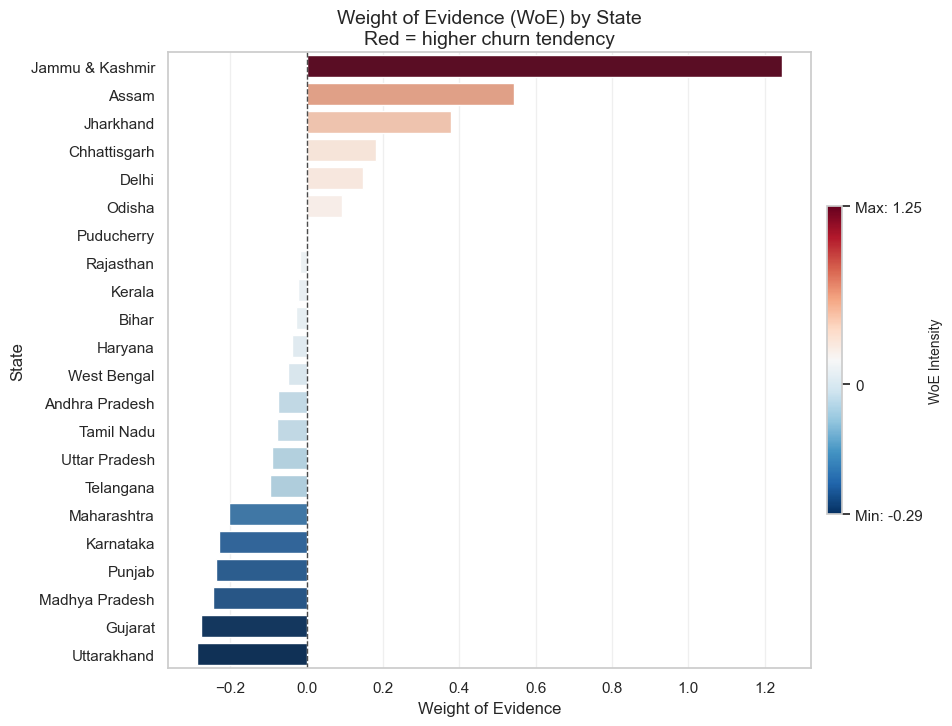

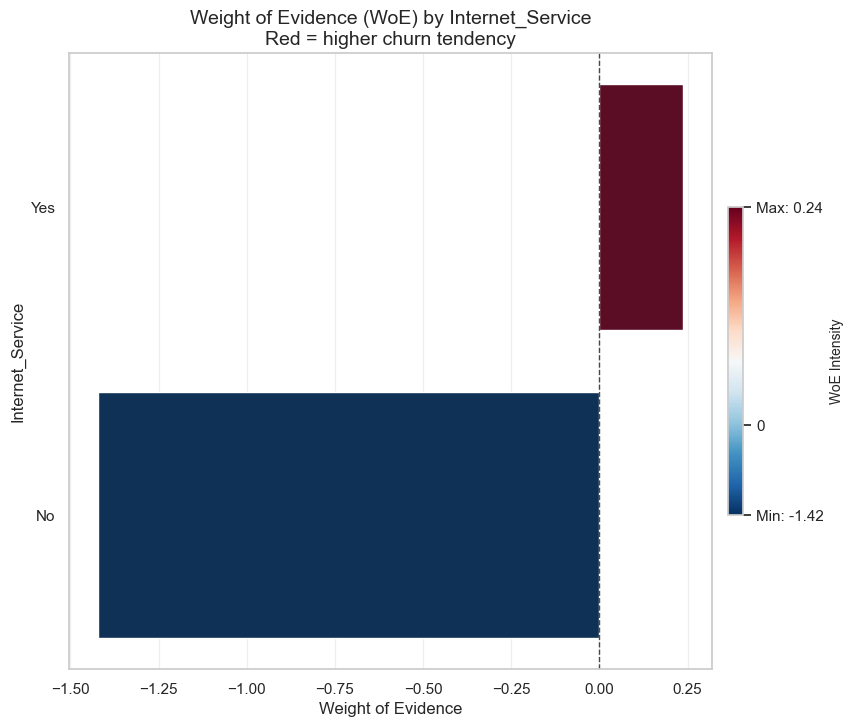

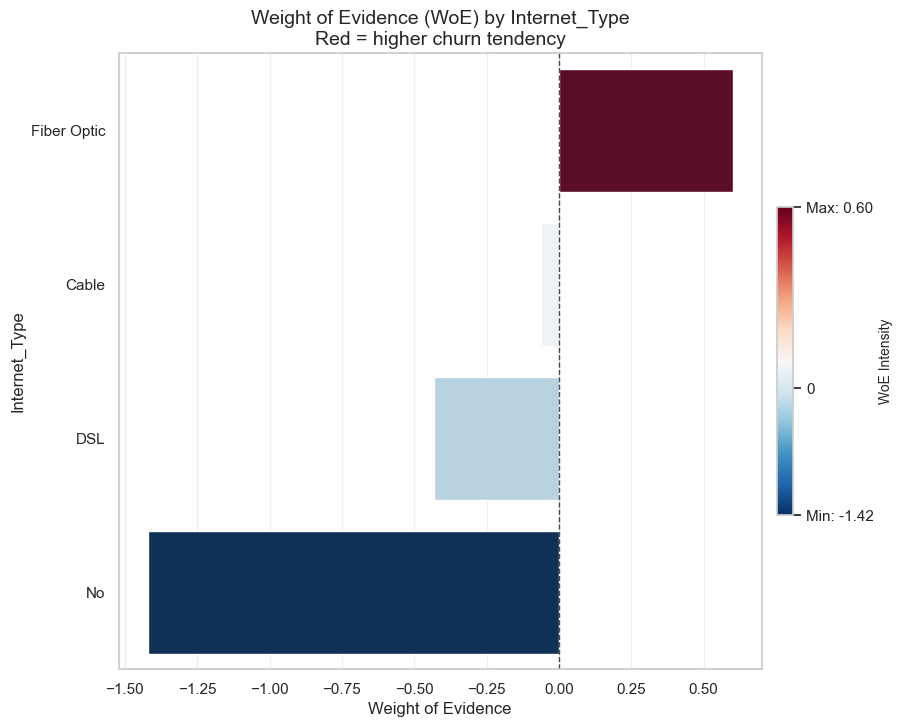

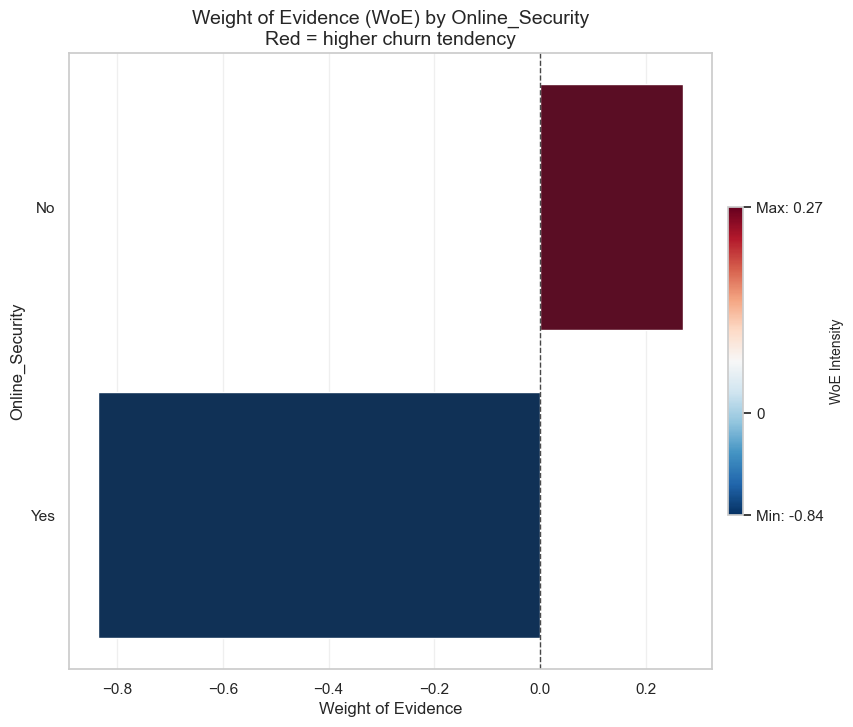

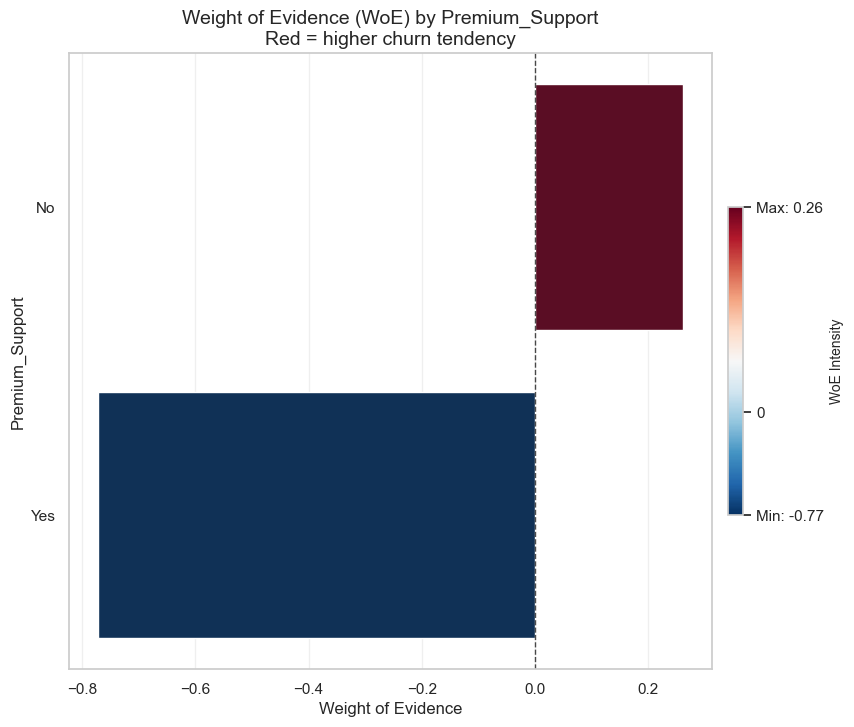

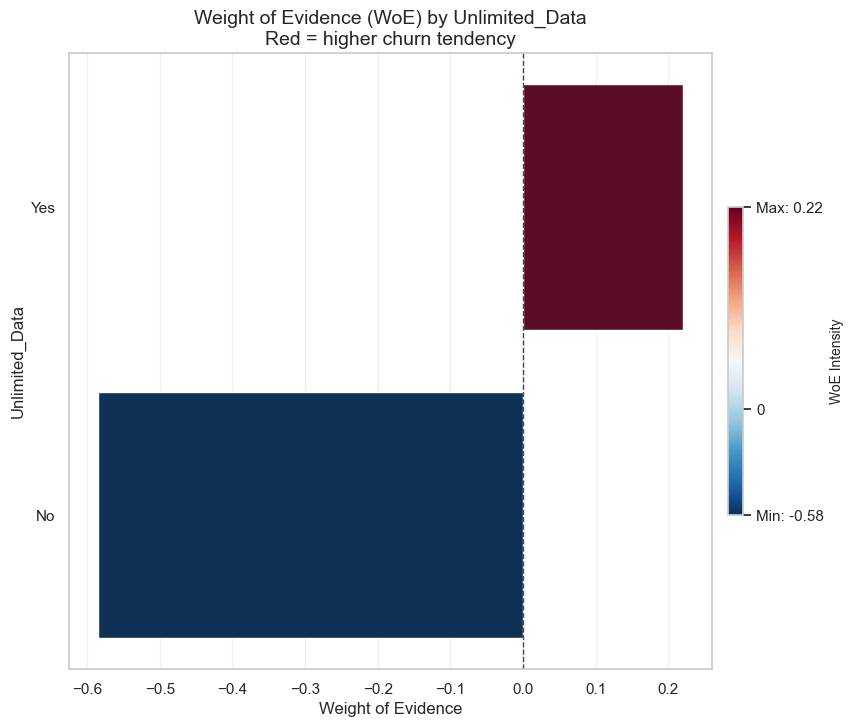

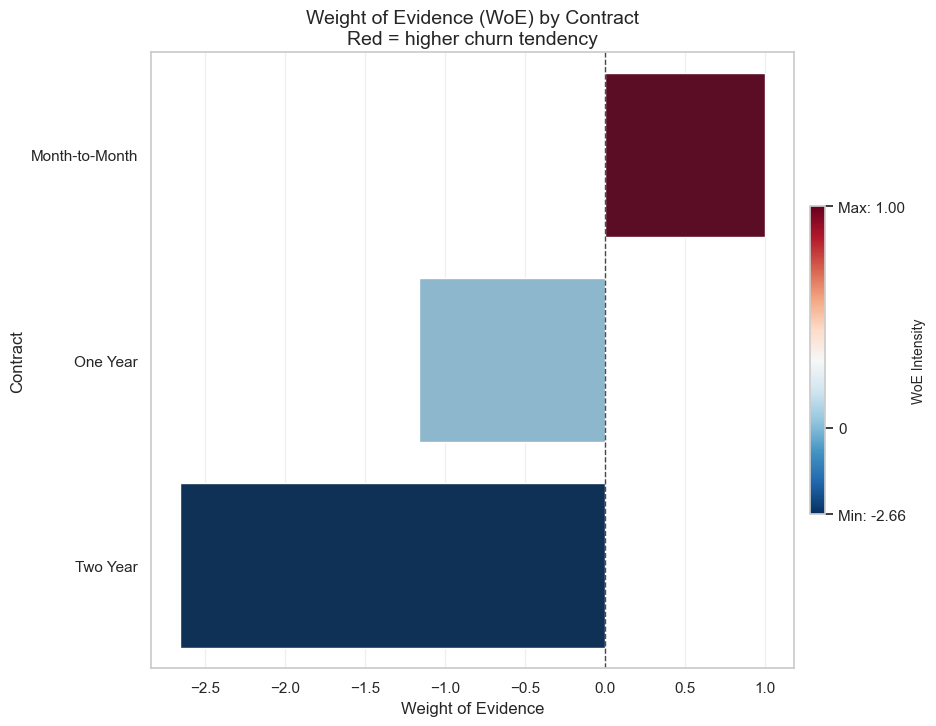

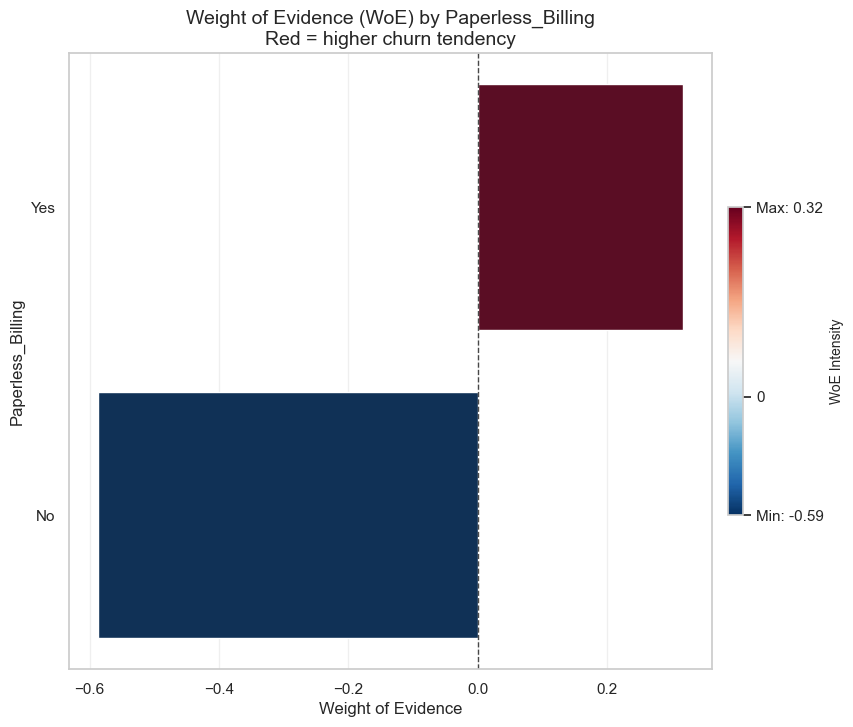

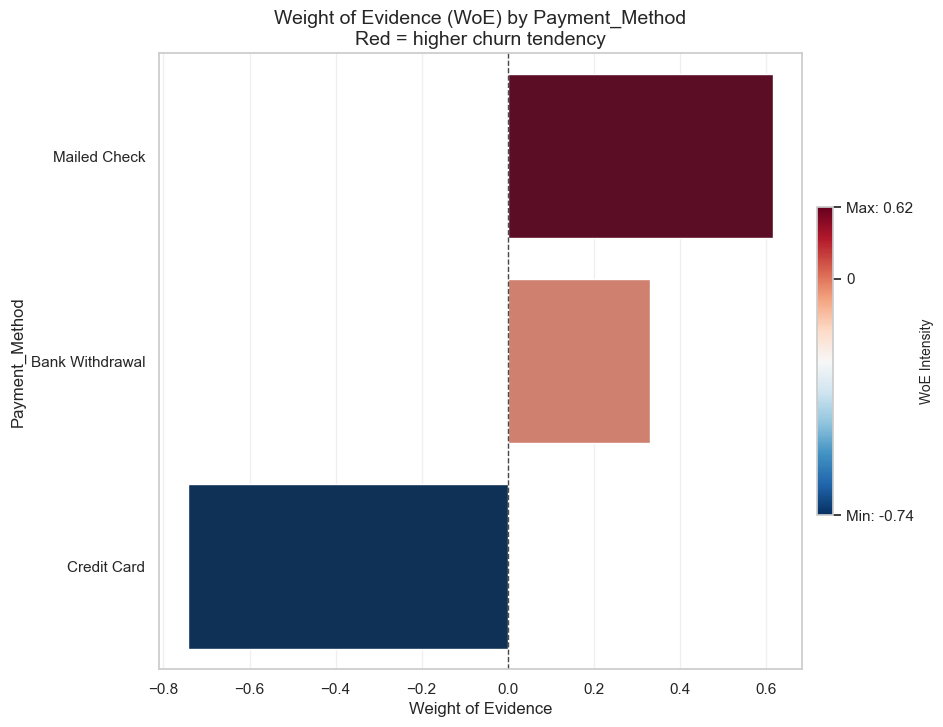

In [180]:
for col in good_iv:
    table_woe = pd.crosstab(churn_stayed[col], churn_stayed['Customer_Status'], normalize = 'columns')
    table_woe = table_woe.replace(0, 0.0001)
    table_woe['WoE'] = np.log(table_woe[1] / table_woe[0])
    
    plot_data = table_woe.sort_values(by='WoE', ascending=False).reset_index()
    
    norm = TwoSlopeNorm(vmin=plot_data['WoE'].min(), vcenter=0, vmax=plot_data['WoE'].max())
    
    scale_cmap = 'RdBu_r' #RdYlGn_r for green-red
    mapper = cm.ScalarMappable(norm=norm, cmap=scale_cmap)
    
    colors = [mapper.to_rgba(x) for x in plot_data['WoE']]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(
        x='WoE', 
        y=col, 
        data=plot_data,
        hue = col,
        palette=colors,
        ax=ax
    )
    
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    vmin = plot_data['WoE'].min()
    vmax = plot_data['WoE'].max()
    
    cbar = fig.colorbar(mapper, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
    cbar.set_ticks([vmin, plot_data['WoE'].median(), vmax])
    cbar.set_ticklabels([f'Min: {vmin:.2f}', '0', f'Max: {vmax:.2f}'])
    
    cbar.set_label('WoE Intensity', fontsize=10)
    
    ax.set_title(f'Weight of Evidence by {col}\nRed = higher churn tendency', fontsize=14)
    ax.set_xlabel('Weight of Evidence', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    
    plt.show()

### 🎲 Odds Ratio (OR)
- Each index of ct is a cluster; iteration over every cluster, and over every category related to each cluster.

In [36]:
results_or = []
from scipy.stats import chi2_contingency

for column in cols_for_cross:
    ct = pd.crosstab(churn_stayed['Clusters'], churn_stayed[column]) 
    chi2, p, dof, ex = chi2_contingency(ct)

    for cluster in ct.index:
        for category in ct.columns:
            a = ct.loc[cluster, category] # cluster x has cat
            b = ct.loc[cluster].sum() - a # cluster x has no cat
            c = ct.loc[:, category].sum()- a # all others with cat
            d = ct.values.sum() - (a + b + c) # all others without cat

            or_val = ((a+0.5) * (d+0.5)) / ((b+0.5) * (c+0.5))
        
            if (or_val > 2 or or_val < 0.5) and p < 0.05:
                impact = 'HIGH' if or_val > 2 else 'LOW'
                results_or.append({
                    'Cluster': cluster,
                    'Feature': column,
                    'p_value': p if p > 0.05 else '<0.05',
                    'Category': category,
                    'Odds_Ratio': or_val,
                    'Propensity': impact,
                })
               
odds_summary = pd.DataFrame(results_or)#.sort_values(by='Odds_Ratio', ascending = False)

Odds_Ratio
0.002340        2
0.000502        2
37563.619718    2
0.001122        2
8.351369        1
               ..
0.468810        1
0.003440        1
0.000452        1
0.001332        1
0.369190        1
Name: count, Length: 90, dtype: int64


#### Dot Plot of Cluster Tendecies

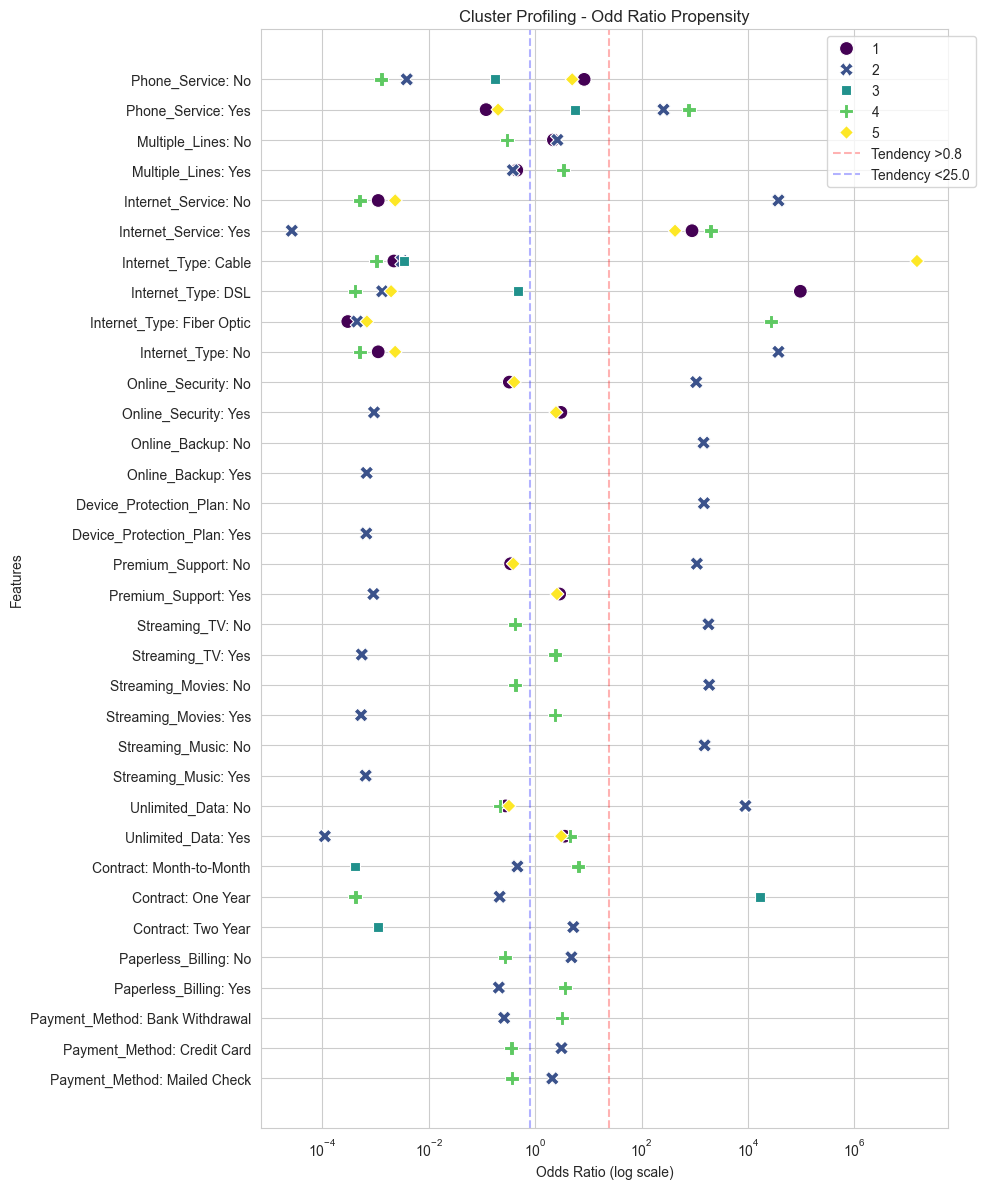

In [59]:
plt.figure(figsize=(10,12))
sns.set_style('whitegrid')

ax=sns.scatterplot(data=df_plot, x= 'Odds_Ratio', y= 'Feature_Cat',
                   hue= 'Cluster', palette='viridis',s=100, style='Cluster')

plt.axvline(x = threshold, color='red', linestyle='--', alpha=0.3, label = f'Tendency >{lower_threshold}')
plt.axvline(x = lower_threshold, color='blue', linestyle='--', alpha=0.3, label = f'Tendency <{threshold}')
plt.xscale('log')  #symmetry
plt.title('Cluster Profiling - Odd Ratio Propensity', fontsize = 12)
plt.xlabel('Odds Ratio (log scale)')
plt.ylabel('Features')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper right')
plt.tight_layout()
plt.show()

#### Profiling on Top/Bottom Features 

In [53]:
upper_threshold = 1.25
lower_threshold = 1 / upper_threshold
df_plot = odds_summary[(odds_summary['Odds_Ratio'] > upper_threshold) |
    (odds_summary['Odds_Ratio'] < upper_threshold)].copy()

df_plot['Feature_Cat'] = df_plot['Feature'] + ': ' + df_plot['Category']

chosen_num = 4
print(f"PROFILING SUMMARY - {chosen_num} TOP & BOTTOM FEATS")

for cluster in sorted(df_plot['Cluster'].unique()):
    top_features = df_plot[df_plot['Cluster'] == cluster].nlargest(chosen_num, 'Odds_Ratio')
    bottom_features = df_plot[df_plot['Cluster'] == cluster].nsmallest(chosen_num, 'Odds_Ratio')

    print(f"\nCLUSTER {cluster}:")
    print(f"💚 Likes: {top_features['Feature_Cat'].values}")
    print(f"💔 Dislikes: {bottom_features['Feature_Cat'].values}")

PROFILING SUMMARY - 4 TOP & BOTTOM FEATS

CLUSTER 1:
💚 Likes: ['Internet_Type: DSL' 'Internet_Service: Yes' 'Phone_Service: No'
 'Unlimited_Data: Yes']
💔 Dislikes: ['Internet_Type: Fiber Optic' 'Internet_Service: No' 'Internet_Type: No'
 'Internet_Type: Cable']

CLUSTER 2:
💚 Likes: ['Internet_Service: No' 'Internet_Type: No' 'Unlimited_Data: No'
 'Streaming_Movies: No']
💔 Dislikes: ['Internet_Service: Yes' 'Unlimited_Data: Yes'
 'Internet_Type: Fiber Optic' 'Streaming_Movies: Yes']

CLUSTER 3:
💚 Likes: ['Contract: One Year' 'Phone_Service: Yes' 'Internet_Type: DSL'
 'Phone_Service: No']
💔 Dislikes: ['Contract: Month-to-Month' 'Contract: Two Year' 'Internet_Type: Cable'
 'Phone_Service: No']

CLUSTER 4:
💚 Likes: ['Internet_Type: Fiber Optic' 'Internet_Service: Yes' 'Phone_Service: Yes'
 'Contract: Month-to-Month']
💔 Dislikes: ['Internet_Type: DSL' 'Contract: One Year' 'Internet_Service: No'
 'Internet_Type: No']

CLUSTER 5:
💚 Likes: ['Internet_Type: Cable' 'Internet_Service: Yes' 'Phone

### COX PH
- Avoid multi-colinearity by choosing unrelated columns, and clusters 

<lifelines.CoxPHFitter: fitted with 6007 total observations, 4275 right-censored observations>
             duration col = 'Tenure_in_Months'
                event col = 'Customer_Status'
      baseline estimation = breslow
   number of observations = 6007
number of events observed = 1732
   partial log-likelihood = -12574.86
         time fit was run = 2026-04-29 01:10:47 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
State              0.45      1.56      0.06            0.34            0.55                1.40                1.74
Internet_Type      0.69      1.99      0.17            0.35            1.03                1.43                2.79
Online_Security    0.42      1.52      0.06            0.29            0.54                1.34                1.71
Premium_Support    0.25      1.29      0.07            0.12            0.38                1.13                1.46
Unlimited_Data     0.05      1.05      0.09           -0.12            0.22                0.88                1.25
Contract           0.66      1.94      0.04            0.59            0.73                1.80                2.08
Paperless_Billing  0.12      1.12      0.06           -0.01            0.24                0.99                1.27
Payment_Method     0.32      1.38      0.05            0.21            0.43                1.24                1.54
Clusters_2         0.18      1.19      0.21           -0.23            0.58                0.80                1.78
Clusters_3        -0.08      0.93      0.20           -0.46            0.31                0.63                1.36
Clusters_4        -0.42      0.66      0.19           -0.79           -0.05                0.45                0.95
Clusters_5         0.11      1.11      0.11           -0.11            0.33                0.89                1.39

                   cmp to     z      p  -log2(p)
covariate                                       
State                0.00  8.09 <0.005     50.58
Internet_Type        0.00  4.03 <0.005     14.14
Online_Security      0.00  6.65 <0.005     34.99
Premium_Support      0.00  3.85 <0.005     13.03
Unlimited_Data       0.00  0.55   0.58      0.78
Contract             0.00 18.22 <0.005    244.04
Paperless_Billing    0.00  1.81   0.07      3.82
Payment_Method       0.00  5.85 <0.005     27.59
Clusters_2           0.00  0.86   0.39      1.35
Clusters_3           0.00 -0.39   0.70      0.52
Clusters_4           0.00 -2.21   0.03      5.22
Clusters_5           0.00  0.95   0.34      1.54
---
Concordance = 0.77
Partial AIC = 25173.71
log-likelihood ratio test = 1652.25 on 12 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(HR) (95% CI)'>

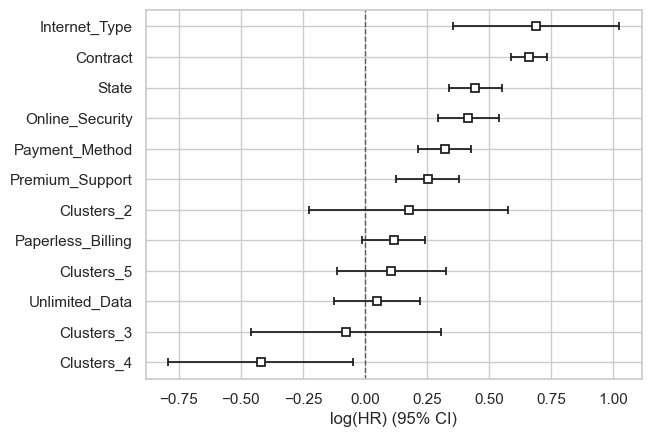

In [201]:
from lifelines import CoxPHFitter

df_cox = df_woe[good_iv + ['Tenure_in_Months', 'Customer_Status','Clusters']].copy()
df_cox = df_cox.dropna()
df_cox = df_cox.drop('Internet_Service', axis=1)
df_cox['Clusters'] = df_cox['Clusters'].astype(str)

# cluster n. 1 becomes the baseline of 1.0, from which all others sprawl
df_dummy = pd.get_dummies(df_cox, columns= ['Clusters'], drop_first = True)

cph = CoxPHFitter()
cph.fit(df_dummy, duration_col = 'Tenure_in_Months', event_col='Customer_Status')
cph.print_summary()
cph.plot()